In [29]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest

## Test1

In [30]:
strategies = [
    ('Momentum', momentum_strategy, 'mom', None, None),
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

In [31]:
assets = ['AAPL']


[*********************100%***********************]  1 of 1 completed

AAPL
Momentum
Market Sharpe Ratio: 0.9056
Best Momentum Strategy window: 14
Best Sharpe ratio: 1.4170

Mean Reversion


Market Sharpe Ratio: 0.9056
Best Mean Reversion Strategy window: 4
Best threshold: 2%
Best Sharpe ratio: 1.0283

Momentum + Trend Strength
Market Sharpe Ratio: 0.9056
Best Momentum + Trend Strength Strategy window: 10
Best Sharpe ratio: 1.1971

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.9056
Best Momentum + Rolling Volatility Strategy window: 14
Best threshold: 2%
Best Sharpe ratio: 1.6868

Momentum + Volume Ratio
Market Sharpe Ratio: 0.9056
Best Momentum + Volume Ratio Strategy window: 20
Best Sharpe ratio: 1.2302

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


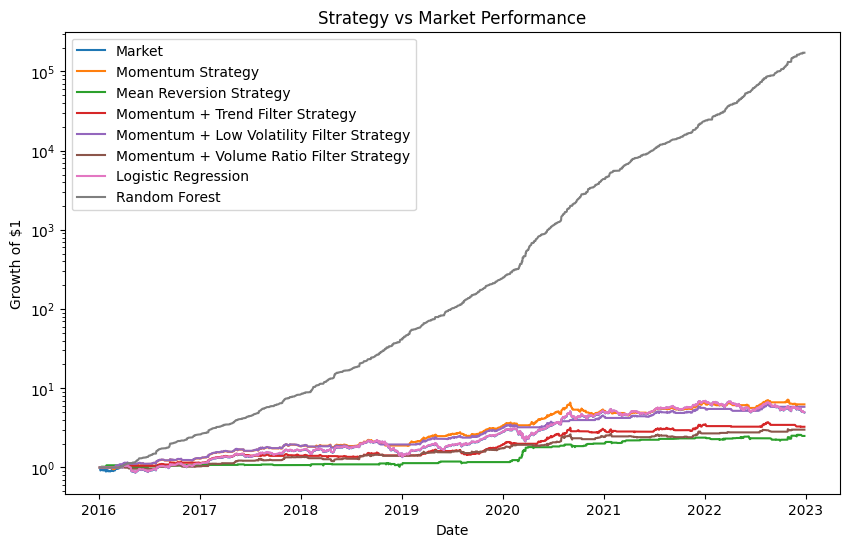

Testing Performance


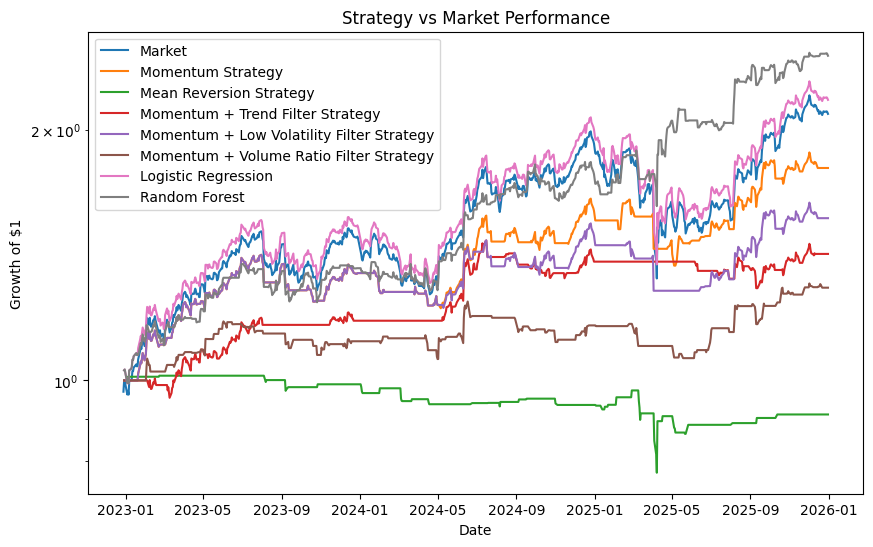


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.905573    0.303760 -0.387297   
1                       Momentum  1.416952    0.199519 -0.313157   
2                 Mean Reversion  1.028301    0.136398 -0.118219   
3      Momentum + Trend Strength  1.197057    0.151061 -0.144578   
4  Momentum + Rolling Volatility  1.686844    0.157121 -0.118903   
5        Momentum + Volume Ratio  1.230180    0.135403 -0.141400   
6            Logistic Regression  0.918925    0.298881 -0.387297   
7                  Random Forest  9.242371    0.189493  0.000000   

   Signal Accuracy  Signal Precision  Signal Recall  
0              NaN               NaN            NaN  
1         0.525867          0.543907       0.651288  
2         0.484935          0.585526       0.095494  
3         0.509380          0.545575       0.443133  
4         0.522456          0.552154       0.522532  
5         0.495736          0.555283       0.

In [32]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    windows=range(2, 50, 2),
    logscale=True
)

## Test 2

In [33]:
strategies = [
    #('Momentum', momentum_strategy, 'mom', None, None),
    #('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    #("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    #("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    #("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

In [34]:
#assets = ['AAPL', 'MSFT','SPY','NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']
assets = ['IBM']

IBM


[*********************100%***********************]  1 of 1 completed

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...


Random Forest model trained and tested.

Training Performance


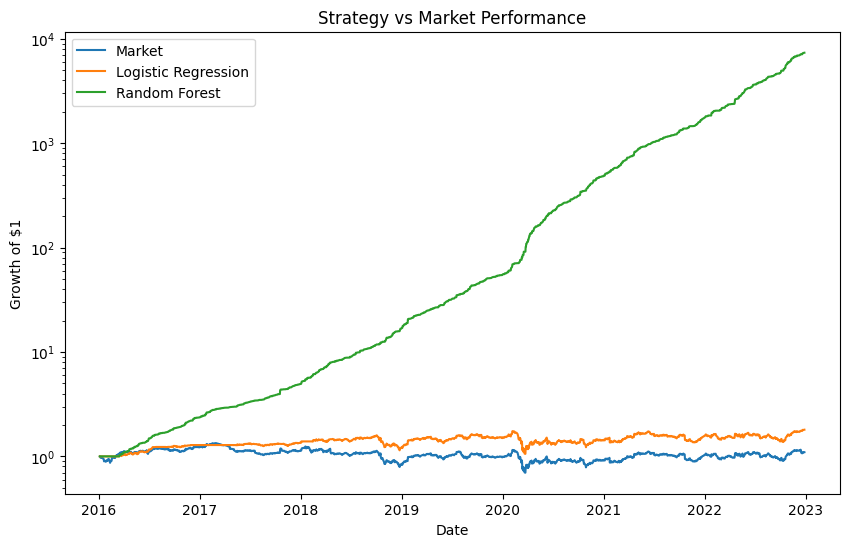

Testing Performance


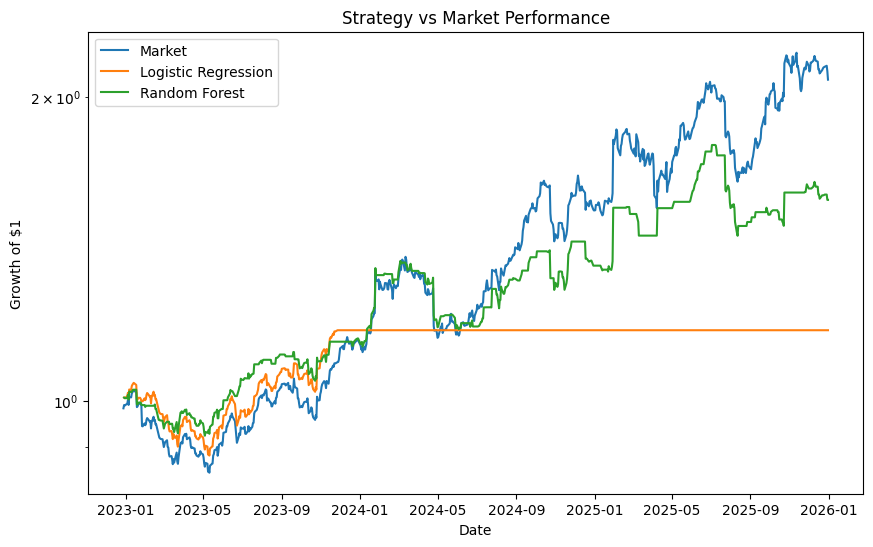


Training Results
              Strategy    Sharpe  Volatility    Max DD  Signal Accuracy  \
0               Market  0.179044    0.252983 -0.479143              NaN   
1  Logistic Regression  0.481675    0.230482 -0.395445         0.527004   
2        Random Forest  8.600737    0.150005  0.000000         0.985219   

   Signal Precision  Signal Recall  
0               NaN            NaN  
1          0.529576       0.829880  
2          1.000000       0.971647  

Testing Results
              Strategy    Sharpe  Volatility    Max DD  Signal Accuracy  \
0               Market  1.139804    0.239352 -0.203576              NaN   
1  Logistic Regression  0.671676    0.085524 -0.152754         0.471523   
2        Random Forest  0.934775    0.181009 -0.186946         0.490066   

   Signal Precision  Signal Recall  
0               NaN            NaN  
1          0.553488       0.281991  
2          0.555891       0.436019  


In [35]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    feature_set='v2',
    windows=range(2, 50, 2),
    logscale=True,
    save_csv=False
)

## Analysis

In [36]:
strategy = [
    'Logistic Regression',
    'Random Forest'
]
featureversion = [None, 'v1']
df = pd.read_csv("../outputs/experiment_results.csv")
df = df[df['Strategy'].isin(strategy)]
df = df[df['Feature Set'].isin(featureversion)]
df

,Asset,Strategy,Feature Set,Window,Threshold,Train Sharpe,Train Volatility,Train Max DD,Train Signal Accuracy,Train Signal Precision,Train Signal Recall,Test Sharpe,Test Volatility,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall
5,AAPL,Logistic Regression,v1,NaN,NaN,0.918925,0.298881,-0.387297,0.525867,0.528655,0.969957,1.138088,0.256622,-0.334337,0.549669,0.549072,1.000000
6,AAPL,Random Forest,v1,NaN,NaN,9.242371,0.189493,0.000000,0.984082,1.000000,0.969957,1.544303,0.208137,-0.142671,0.544371,0.573840,0.657005
12,MSFT,Logistic Regression,v1,NaN,NaN,0.927021,0.275509,-0.375565,0.537237,0.537331,0.971307,1.157835,0.231676,-0.241680,0.540397,0.540721,0.992647
13,MSFT,Random Forest,v1,NaN,NaN,9.083516,0.175537,0.000000,0.986924,1.000000,0.975558,0.387206,0.175917,-0.220776,0.491391,0.528846,0.539216
19,SPY,Logistic Regression,v1,NaN,NaN,0.549230,0.186428,-0.363393,0.541785,0.544648,0.962382,1.491739,0.151211,-0.175632,0.573510,0.572764,0.995360
20,SPY,Random Forest,v1,NaN,NaN,8.678254,0.113625,0.000000,0.984650,1.000000,0.971787,1.263144,0.112150,-0.155793,0.519205,0.569959,0.642691
26,NVDA,Logistic Regression,v1,NaN,NaN,1.079549,0.492507,-0.663621,0.540080,0.542105,0.972718,1.972225,0.501538,-0.368868,0.553642,0.553642,1.000000
27,NVDA,Random Forest,v1,NaN,NaN,9.325382,0.318387,0.000000,0.985219,1.000000,0.972718,1.346436,0.373690,-0.439506,0.517881,0.563981,0.569378
33,TTD,Logistic Regression,v1,NaN,NaN,0.948205,0.668868,-0.687122,0.529700,0.531169,0.946759,0.204866,0.544758,-0.753254,0.540000,0.538123,0.981283
34,TTD,Random Forest,v1,NaN,NaN,7.679921,0.522543,0.000000,0.983466,1.000000,0.968750,-0.323597,0.470715,-0.772215,0.480000,0.514706,0.467914


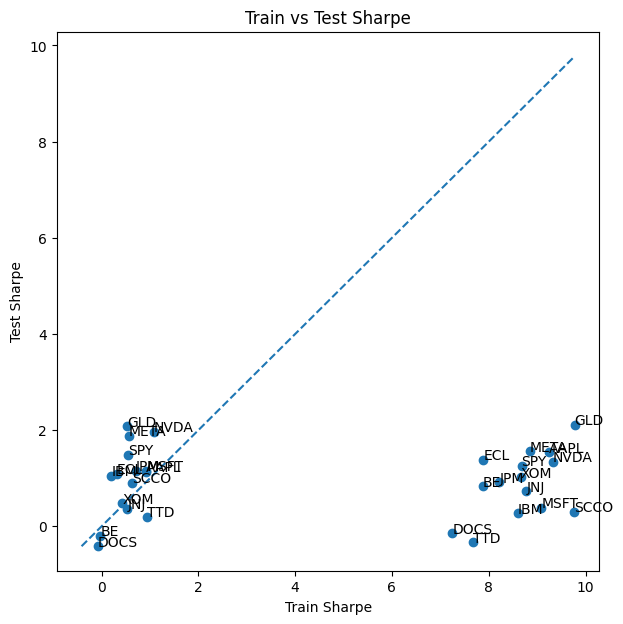

In [37]:
plt.figure(figsize=(7,7))

plt.scatter(df["Train Sharpe"], df["Test Sharpe"])

lims = [
    min(df["Train Sharpe"].min(), df["Test Sharpe"].min()),
    max(df["Train Sharpe"].max(), df["Test Sharpe"].max())
]

plt.plot(lims, lims, "--")

for _, row in df.iterrows():
    plt.text(
        row["Train Sharpe"],
        row["Test Sharpe"],
        row["Asset"]
    )

plt.xlabel("Train Sharpe")
plt.ylabel("Test Sharpe")
plt.title("Train vs Test Sharpe")

plt.show()

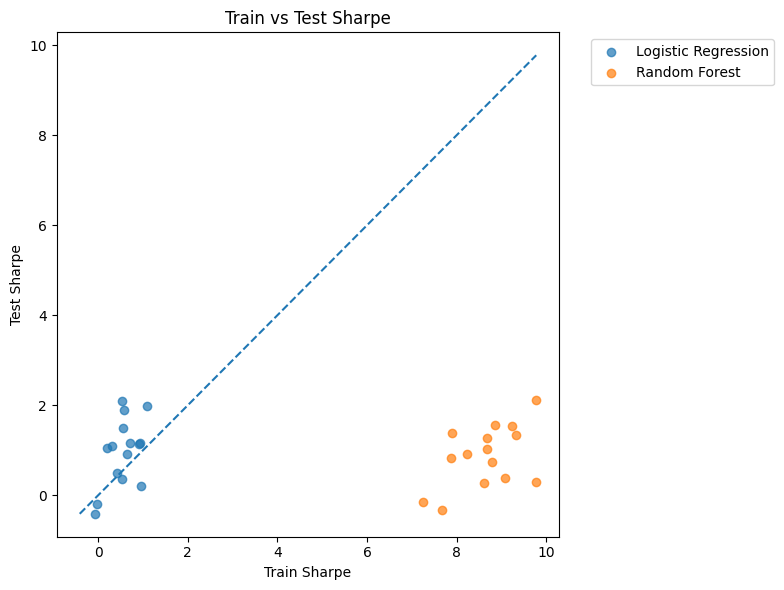

In [38]:
plt.figure(figsize=(8,6))

for strategy in df["Strategy"].unique():

    subset = df[df["Strategy"] == strategy]

    plt.scatter(
        subset["Train Sharpe"],
        subset["Test Sharpe"],
        label=strategy,
        alpha=0.7
    )

lims = [
    min(df["Train Sharpe"].min(), df["Test Sharpe"].min()),
    max(df["Train Sharpe"].max(), df["Test Sharpe"].max())
]

plt.plot(lims, lims, "--")

plt.xlabel("Train Sharpe")
plt.ylabel("Test Sharpe")
plt.title("Train vs Test Sharpe")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

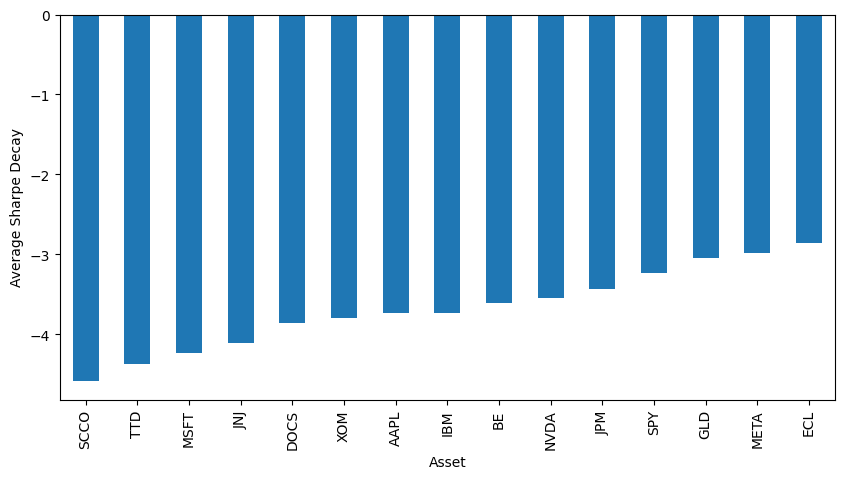

In [39]:
df["Decay"] = (
    df["Test Sharpe"] -
    df["Train Sharpe"]
)

decay = (
    df.groupby("Asset")["Decay"]
      .mean()
      .sort_values()
)

decay.plot.bar(figsize=(10,5))

plt.ylabel("Average Sharpe Decay")

plt.show()

In [ ]:
summary = (
    df.groupby("Asset")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean",
          "Test Signal Accuracy":"mean",
          "Test Signal Precision":"mean",
          "Test Signal Recall":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Train Volatility,Test Volatility,Train Max DD,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall
Asset,,,,,,,,,
GLD,5.150183,2.100310,0.107734,0.128196,-0.094867,-0.106823,0.539735,0.572108,0.736967
META,4.711293,1.725325,0.266549,0.281108,-0.246664,-0.248838,0.521854,0.539231,0.659601
NVDA,5.202465,1.659330,0.405447,0.437614,-0.331810,-0.404187,0.535762,0.558812,0.784689
SPY,4.613742,1.377441,0.150026,0.131680,-0.181697,-0.165713,0.546358,0.571361,0.819026
AAPL,5.080648,1.341195,0.244187,0.232379,-0.193648,-0.238504,0.547020,0.561456,0.828502
ECL,4.102486,1.243770,0.215953,0.180033,-0.221326,-0.129576,0.536424,0.553224,0.802920
JPM,4.467039,1.035962,0.217289,0.176233,-0.165327,-0.234095,0.509272,0.563095,0.603972
MSFT,5.005268,0.772521,0.225523,0.203797,-0.187782,-0.231228,0.515894,0.534784,0.765931
XOM,4.546782,0.754582,0.205660,0.179035,-0.189925,-0.166730,0.529801,0.534177,0.677461


In [ ]:
plt.figure(figsize=(10,5))

df.boxplot(
    column="Test Sharpe",
    by="Strategy",
    rot=30
)

plt.title("Test Sharpe by Strategy")
plt.suptitle("")
plt.ylabel("Sharpe")

plt.show()

TypeError: unsupported operand type(s) for &: 'str' and 'str'

<Figure size 1000x500 with 0 Axes>

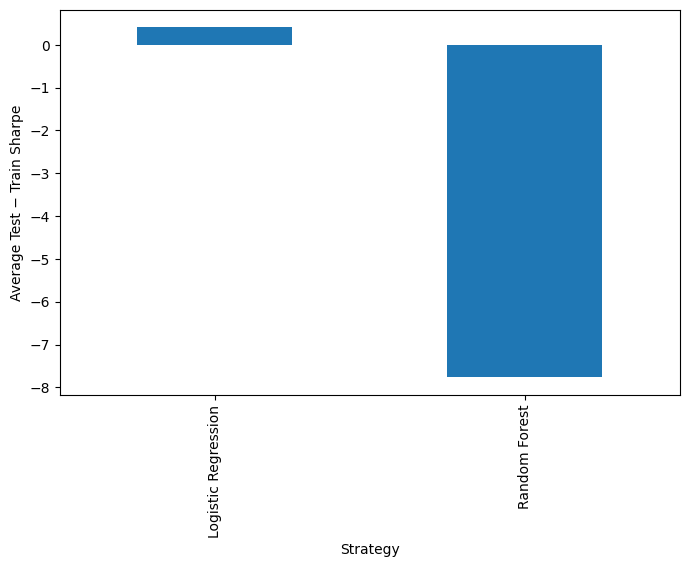

In [42]:
df["Sharpe Decay"] = (
    df["Test Sharpe"] -
    df["Train Sharpe"]
)

decay = (
    df.groupby("Strategy")["Sharpe Decay"]
      .mean()
)

decay.plot.bar(figsize=(8,5))

plt.ylabel("Average Test − Train Sharpe")

plt.show()

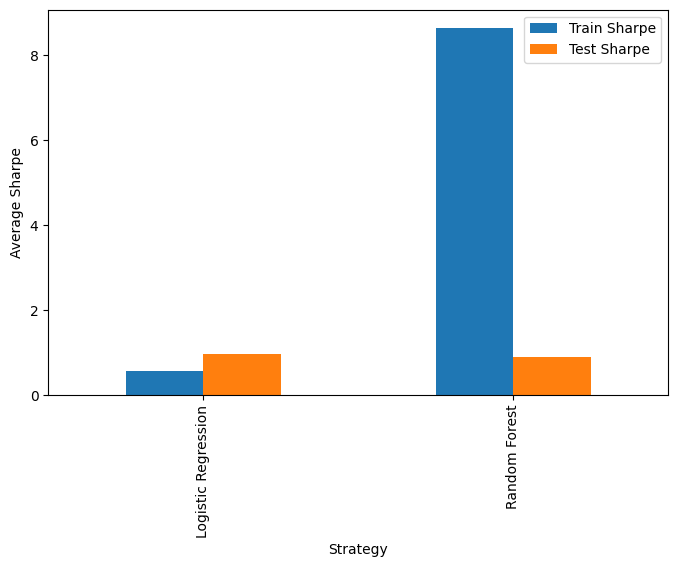

In [43]:
summary = (
    df.groupby("Strategy")
      [["Train Sharpe","Test Sharpe"]]
      .mean()
)

summary.plot.bar(figsize=(8,5))

plt.ylabel("Average Sharpe")
plt.show()

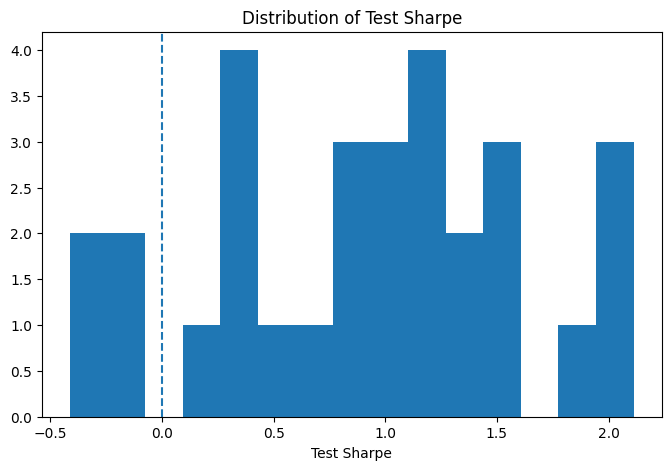

In [45]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Test Sharpe"],
    bins=15
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Test Sharpe")
plt.title("Distribution of Test Sharpe")

plt.show()

In [46]:
metrics = df[[
    "Train Sharpe",
    "Train Volatility",
    "Train Max DD",
    "Train Signal Accuracy",
    "Train Signal Precision",
    "Train Signal Recall",
    "Test Sharpe",
    "Test Volatility",
    "Test Max DD",
    "Test Signal Accuracy",
    "Test Signal Precision",
    "Test Signal Recall"
]]

metrics.corr()

,Train Sharpe,Train Volatility,Train Max DD,Train Signal Accuracy,Train Signal Precision,Train Signal Recall,Test Sharpe,Test Volatility,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall
Train Sharpe,1.000000,-0.170775,0.882979,0.991573,0.990146,0.399716,0.009617,0.002325,0.011133,-0.389034,0.201596,-0.483010
Train Volatility,-0.170775,1.000000,-0.369443,-0.136100,-0.130445,0.074901,-0.253600,0.958409,-0.831253,-0.111316,-0.362920,0.106508
Train Max DD,0.882979,-0.369443,1.000000,0.898750,0.900918,0.185868,-0.092077,-0.226677,0.223826,-0.491797,0.083872,-0.607362
Train Signal Accuracy,0.991573,-0.136100,0.898750,1.000000,0.999803,0.367883,-0.044660,0.025899,-0.002083,-0.437599,0.143174,-0.524770
Train Signal Precision,0.990146,-0.130445,0.900918,0.999803,1.000000,0.360788,-0.051351,0.030870,-0.004134,-0.445785,0.135107,-0.531933
Train Signal Recall,0.399716,0.074901,0.185868,0.367883,0.360788,1.000000,0.461754,0.213341,-0.169671,0.417913,0.635872,0.576912
Test Sharpe,0.009617,-0.253600,-0.092077,-0.044660,-0.051351,0.461754,1.000000,-0.144152,0.392145,0.719618,0.750255,0.507534
Test Volatility,0.002325,0.958409,-0.226677,0.025899,0.030870,0.213341,-0.144152,1.000000,-0.804322,-0.133466,-0.298790,0.087433
Test Max DD,0.011133,-0.831253,0.223826,-0.002083,-0.004134,-0.169671,0.392145,-0.804322,1.000000,0.210066,0.283239,-0.076647
Test Signal Accuracy,-0.389034,-0.111316,-0.491797,-0.437599,-0.445785,0.417913,0.719618,-0.133466,0.210066,1.000000,0.655658,0.837213


In [47]:
df["Sharpe Ratio"] = np.where(
    df["Train Sharpe"] != 0,
    df["Test Sharpe"] / df["Train Sharpe"],
    np.nan
)

In [48]:
summary = (
    df.groupby("Strategy")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean",
          "Train Signal Accuracy":"mean",
          "Test Signal Accuracy":"mean",
          "Train Signal Precision":"mean",
          "Test Signal Precision":"mean",
          "Train Signal Recall":"mean",
          "Test Signal Recall":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Train Volatility,Test Volatility,Train Max DD,Test Max DD,Train Signal Accuracy,Test Signal Accuracy,Train Signal Precision,Test Signal Precision,Train Signal Recall,Test Signal Recall
Strategy,,,,,,,,,,,,
Logistic Regression,0.549073,0.959970,0.288157,0.249986,-0.410925,-0.267361,0.525199,0.532806,0.527338,0.536432,0.805352,0.814358
Random Forest,8.645609,0.881914,0.248711,0.257334,0.000000,-0.268038,0.983202,0.506695,1.000000,0.544055,0.967308,0.529013
